In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt

import sys, os, glob
# the chapter programs live in BookPrograms/chapterNN; put them all on the path
for _d in sorted(glob.glob(os.path.join("..", "BookManybody",
                                        "BookPrograms", "chapter*"))):
    if _d not in sys.path:
        sys.path.insert(0, _d)
import hartreefock as hf

np.set_printoptions(precision=6, suppress=True, linewidth=120)

In [2]:
hf.demo_scf()

1. The self-consistent field loop
Spinless fermions in a one-dimensional oscillator trap with a
softened Coulomb repulsion, eight oscillator orbitals.  Each
iteration builds the density matrix, builds the Fock matrix and
diagonalises it -- chapter 1 inside chapter 2's eigenvalue problem.



  N  iterations    E(reference)   E(Hartree-Fock)         gain
  2          17      2.69018342        2.66308878    -2.71e-02
  3          17      6.46801021        6.39016133    -7.78e-02
  4          17     11.77084712       11.62305385    -1.48e-01

Brillouin's theorem at convergence: max |f_ai| = 8.72e-11
The reference no longer couples to the singles, which is what
empties the 0p0h-1p1h block of the configuration-interaction
matrix of chapter 5.


In [3]:
h0, v = hf.trap_system(n_orbitals=8)
scf = hf.SelfConsistentField(h0, v, n_particles=4)
scf.run(verbose=True)

rho = scf.density(scf.C)
print("\ntrace of rho          :", np.trace(rho))
print("|rho^2 - rho|         :", np.abs(rho @ rho - rho).max())
print("eigenvalues of rho    :", np.linalg.eigvalsh(rho))
print("\nmax |f_ai| (Brillouin):", f"{scf.brillouin():.2e}")

     1  E =  11.6292802325   mean |d eps| = 6.061e+00
     2  E =  11.6234352328   mean |d eps| = 4.016e-02
     3  E =  11.6230795358   mean |d eps| = 7.021e-03
     4  E =  11.6230556432   mean |d eps| = 1.519e-03
     5  E =  11.6230539759   mean |d eps| = 3.675e-04
     6  E =  11.6230538563   mean |d eps| = 9.108e-05
     7  E =  11.6230538475   mean |d eps| = 2.283e-05
     8  E =  11.6230538469   mean |d eps| = 6.102e-06
     9  E =  11.6230538468   mean |d eps| = 1.666e-06
    10  E =  11.6230538468   mean |d eps| = 4.575e-07
    11  E =  11.6230538468   mean |d eps| = 1.262e-07
    12  E =  11.6230538468   mean |d eps| = 3.500e-08
    13  E =  11.6230538468   mean |d eps| = 9.747e-09
    14  E =  11.6230538468   mean |d eps| = 2.725e-09
    15  E =  11.6230538468   mean |d eps| = 7.649e-10
    16  E =  11.6230538468   mean |d eps| = 2.154e-10
    17  E =  11.6230538468   mean |d eps| = 6.084e-11

trace of rho          : 3.9999999999999987
|rho^2 - rho|         : 7.771561172376

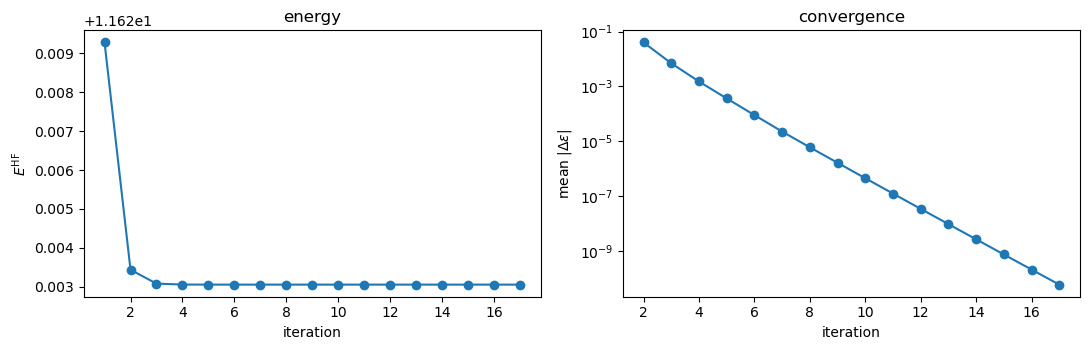

In [4]:
it, energies, drifts = zip(*scf.history)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(it, energies, "o-")
ax[0].set_xlabel("iteration"); ax[0].set_ylabel(r"$E^{\rm HF}$")
ax[0].set_title("energy")
ax[1].semilogy(it[1:], drifts[1:], "o-")
ax[1].set_xlabel("iteration")
ax[1].set_ylabel(r"mean $|\Delta\varepsilon|$")
ax[1].set_title("convergence")
fig.tight_layout()
plt.show()

In [5]:
hf.demo_pairing()

2. Hartree-Fock does nothing for the pairing model
     g    E(reference)   E(Hartree-Fock)        E(exact)  iterations
  0.25      1.75000000        1.75000000      1.73045985           2
  0.50      1.50000000        1.50000000      1.41677428           2
  1.00      1.00000000        1.00000000      0.63554847           2

The pairing interaction moves whole pairs and cannot change the
seniority, so <Phi_0|H|Phi_i^a> = 0 in any basis and the Fock
matrix is diagonal from the first iteration.  Hartree-Fock buys
nothing at all: the whole correlation energy of chapter 5 has to
come from the doubles.  A mean field is only as useful as the
one-body physics the interaction actually contains.


In [6]:
hf.demo_thouless()

3. Thouless' theorem
Six orbitals, three particles, random amplitudes C_ai of size 0.3.

   max |[T_i, T_j]|                 2.776e-17
   max |T_i^2|                      0.000e+00
   |exp(T)|c> - prod_i b^+_i|0>|    5.551e-17
   <c|exp(T)|c>                     1.000000000000
   det of the occupied block of D   1.000000000000

The one-particle-one-hole operators commute and each squares to
zero, so the exponential collapses to a product of N factors and
the result is the single determinant built from
b^+_i = a^+_i + sum_a C_ai a^+_a.  Its overlap with the reference
is one, so the rotated determinant is never orthogonal to the one
we started from -- exactly the freedom Hartree-Fock explores.

The exponential is not the same as its linear truncation: the
cross terms T_i T_j with i /= j survive and are 2p-2h admixtures.
They are second order in the amplitudes, which is why keeping
only 1p-1h is legitimate for an infinitesimal variation:

   scale s     |exp(sT)|c> - (1+sT)|c>|    ratio
 

In [7]:
hf.demo_stability()

4. Stability of the Hartree-Fock solution
The Lipkin model with N = 4 and W = 0.  The mean-field energy is
E(alpha)/N = -(eps/2)cos(alpha) - (eps chi/4)sin^2(alpha), with
chi = V(N-1)/eps.  The spherical solution alpha = 0 is a minimum
only while chi < 1.

   chi        V    lowest eig of M   alpha_min         E_mf      E_exact   deformed
  0.25   0.0833         0.75000000    0.000000    -2.000000    -2.020726      False
  0.50   0.1667         0.50000000    0.000000    -2.000000    -2.081666      False
  0.90   0.3000         0.10000000    0.000000    -2.000000    -2.253886      False
  1.00   0.3333        -0.00000000    0.000000    -2.000000    -2.309401      False
  1.50   0.5000        -0.50000000    0.841069    -2.166667    -2.645751       True
  2.00   0.6667        -1.00000000    1.047198    -2.500000    -3.055050       True

The lowest eigenvalue of M reaches zero exactly at chi = 1, where
the deformed solution appears.  Beyond that the spherical
Hartree-Fock state is a saddle

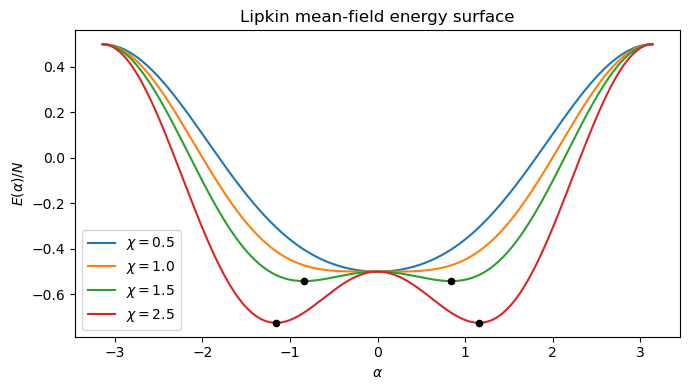

In [8]:
# the mean-field energy surface on either side of the transition
alpha = np.linspace(-np.pi, np.pi, 400)
fig, ax = plt.subplots(figsize=(7, 4))
for chi in (0.5, 1.0, 1.5, 2.5):
    model = hf.LipkinHF(N=4, eps=1.0, V=chi / 3.0)
    ax.plot(alpha, model.mean_field_energy(alpha) / model.N,
            label=rf"$\chi = {chi}$")
    a_min, e_min, deformed = model.mean_field_minimum()
    if deformed:
        ax.plot([a_min, -a_min], [e_min / model.N] * 2, "k.", ms=9)
ax.set_xlabel(r"$\alpha$"); ax.set_ylabel(r"$E(\alpha)/N$")
ax.set_title("Lipkin mean-field energy surface")
ax.legend(); fig.tight_layout(); plt.show()

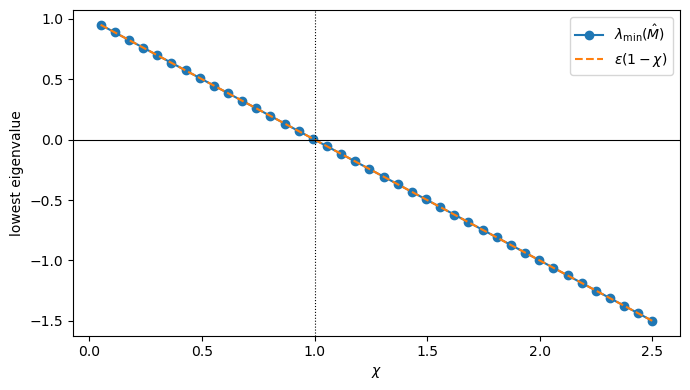

In [9]:
# the lowest eigenvalue of M crosses zero exactly at chi = 1
chis = np.linspace(0.05, 2.5, 40)
lowest = []
for chi in chis:
    model = hf.LipkinHF(N=4, eps=1.0, V=chi / 3.0)
    S = hf.StabilityMatrix(model.matrix(), model.states, model.index,
                           model.reference, model.N, model.n)
    lowest.append(S.eigenvalues()[0])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(chis, lowest, "o-", label=r"$\lambda_{\min}(\hat M)$")
ax.plot(chis, 1.0 - chis, "--", label=r"$\varepsilon(1-\chi)$")
ax.axhline(0.0, color="k", lw=0.8)
ax.axvline(1.0, color="k", lw=0.8, ls=":")
ax.set_xlabel(r"$\chi$"); ax.set_ylabel("lowest eigenvalue")
ax.legend(); fig.tight_layout(); plt.show()

In [10]:
hf.demo_bch()

5. The Baker-Campbell-Hausdorff expansion
A = [[0, 0.1], [0, 0]],  B = [[0, 0], [0.1, 0]],  [A, B] != 0.

 order                                   terms kept    || e^A e^B - e^Z ||
     1                                        X + Y              7.075e-03
     2                                 + (1/2)[X,Y]              2.379e-04
     3              + (1/12)([X,[X,Y]] + [Y,[Y,X]])              1.179e-05
     4                        - (1/24)[Y,[X,[X,Y]]]              4.757e-07

Each extra commutator gains roughly two orders of magnitude for
these amplitudes.  The series is asymptotic, not convergent for
arbitrary operators, but the operators appearing in Thouless'
theorem are special: there [A, B] = 0 for every pair, the series
stops at the first term, and the exponential is exact.


In [11]:
# compare the truncated series against the exact logarithm
A = np.array([[0.0, 0.1], [0.0, 0.0]])
B = np.array([[0.0, 0.0], [0.1, 0.0]])
Z_exact = hf.bch_exact_log(A, B).real
print("exact  Z = log(e^A e^B):\n", Z_exact)
for n in (1, 2, 3, 4):
    Z = hf.bch_series(A, B, n)
    print(f"order {n}:  ||Z_n - Z|| = {np.linalg.norm(Z - Z_exact):.3e}")

exact  Z = log(e^A e^B):
 [[ 0.004992  0.099834]
 [ 0.099834 -0.004992]]
order 1:  ||Z_n - Z|| = 7.063e-03
order 2:  ||Z_n - Z|| = 2.355e-04
order 3:  ||Z_n - Z|| = 1.177e-05
order 4:  ||Z_n - Z|| = 4.710e-07


In [12]:
hf.demo_trotter()

6. The Trotter-Suzuki splitting
A single qubit with H = sigma_x + sigma_z, t = 1, [X, Z] = -2i Y.

    N      first order    ratio     second order    ratio
    1        1.130e+00                 4.436e-01         
    2        5.125e-01     2.21        1.006e-01     4.41
    4        2.493e-01     2.06        2.443e-02     4.12
    8        1.238e-01     2.01        6.061e-03     4.03
   16        6.177e-02     2.00        1.513e-03     4.01
   32        3.087e-02     2.00        3.779e-04     4.00
   64        1.543e-02     2.00        9.448e-05     4.00

Halving the step size halves the first-order error and quarters
the second-order one: the global errors are O(t^2/N) and
O(t^3/N^2), exactly as the leading commutators of the BCH series
predict.


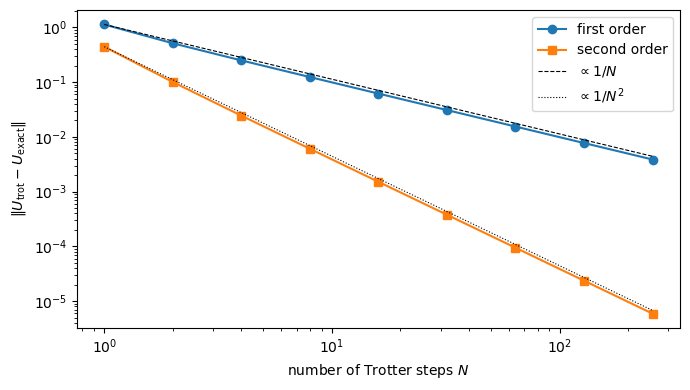

In [13]:
X = np.array([[0.0, 1.0], [1.0, 0.0]])
Z = np.array([[1.0, 0.0], [0.0, -1.0]])
rows = hf.trotter_error(X, Z, t=1.0, steps=(1, 2, 4, 8, 16, 32, 64, 128, 256))
N, e1, e2 = np.array(rows).T

fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(N, e1, "o-", label="first order")
ax.loglog(N, e2, "s-", label="second order")
ax.loglog(N, e1[0] / N, "k--", lw=0.8, label=r"$\propto 1/N$")
ax.loglog(N, e2[0] / N**2, "k:", lw=0.8, label=r"$\propto 1/N^2$")
ax.set_xlabel("number of Trotter steps $N$")
ax.set_ylabel(r"$\|U_{\rm trot} - U_{\rm exact}\|$")
ax.legend(); fig.tight_layout(); plt.show()

In [14]:
hf.demo_electron_gas()

7. The infinite homogeneous electron gas
Hartree-Fock single-particle energy, r_s/a_0 = 4:
 x = k/k_F         F(x)     eps^HF/eps_0^F       free
      0.00     1.000000          -2.652000     0.0000
      0.25     0.978899          -2.533540     0.0625
      0.50     0.911980          -2.168570     0.2500
      0.75     0.783779          -1.516081     0.5625
      1.00     0.500000          -0.326000     1.0000
      1.25     0.252812           0.892042     1.5625
      1.50     0.164700           1.813214     2.2500
      2.00     0.088020           3.766570     4.0000

band width  eps(k_F) - eps(0)  = 2.3260
closed form 1 + 0.3315 r_s/a_0 = 2.3260
(the free gas has a band width of exactly 1, so the exchange term
 more than doubles it)

Effective mass just below the Fermi surface:
   1 - x =  1.0e-02    m*_HF / m = 0.256074
   1 - x =  1.0e-03    m*_HF / m = 0.184829
   1 - x =  1.0e-04    m*_HF / m = 0.144226
   1 - x =  1.0e-05    m*_HF / m = 0.118208
   1 - x =  1.0e-06    m*_HF / 

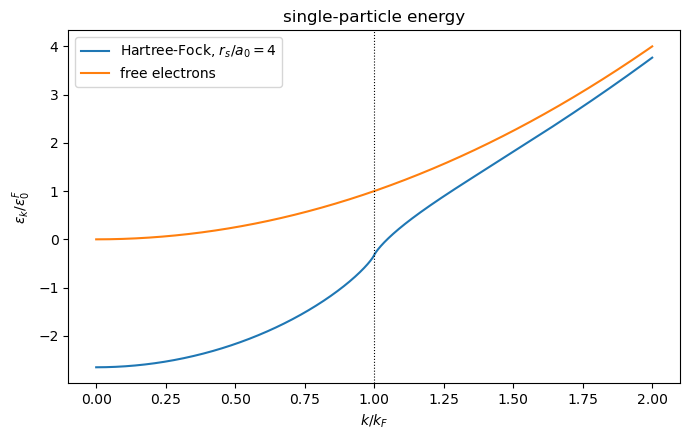

band width, Hartree-Fock : 2.3260
band width, free gas     : 1.0000
Exchange more than doubles the width of the occupied band.


In [15]:
gas = hf.ElectronGas(rs_over_a0=4.0)
x = np.linspace(1e-6, 2.0, 800)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(x, gas.energy(x), label=r"Hartree-Fock, $r_s/a_0 = 4$")
ax.plot(x, x**2, label="free electrons")
ax.axvline(1.0, color="k", lw=0.8, ls=":")
ax.set_xlabel(r"$k/k_F$")
ax.set_ylabel(r"$\varepsilon_k / \varepsilon_0^F$")
ax.set_title("single-particle energy")
ax.legend(); fig.tight_layout(); plt.show()

print(f"band width, Hartree-Fock : {gas.band_width():.4f}")
print(f"band width, free gas     : 1.0000")
print("Exchange more than doubles the width of the occupied band.")

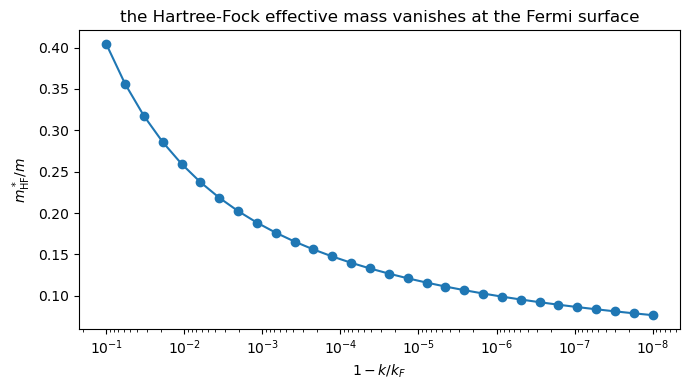

In [16]:
deltas = np.logspace(-1, -8, 30)
mstar = [gas.effective_mass(d) for d in deltas]

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(deltas, mstar, "o-")
ax.invert_xaxis()
ax.set_xlabel(r"$1 - k/k_F$")
ax.set_ylabel(r"$m^*_{\rm HF} / m$")
ax.set_title("the Hartree-Fock effective mass vanishes at the Fermi surface")
fig.tight_layout(); plt.show()

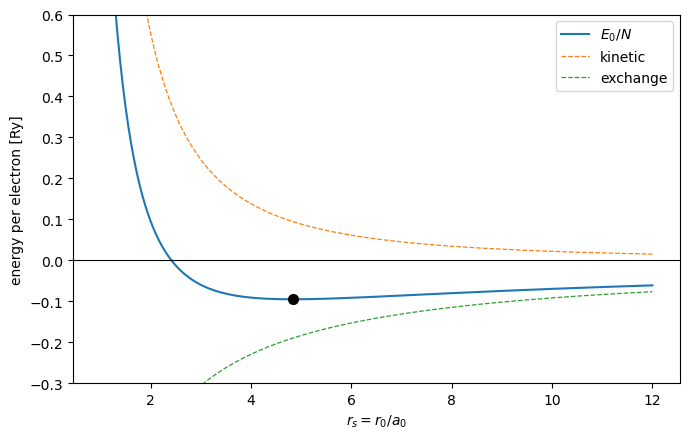

equilibrium at r_s = 4.8253
E_0/N = -0.094916 Ry = -1.2914 eV
For comparison, the correlation energy near equilibrium is about
-0.06 Ry, so exchange alone accounts for roughly half the binding.


In [17]:
rs = np.linspace(1.0, 12.0, 400)
E = hf.ElectronGas.energy_per_electron(rs)
rs_eq, e_eq = hf.ElectronGas.equilibrium()

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(rs, E, label=r"$E_0/N$")
ax.plot(rs, 2.21 / rs**2, "--", lw=0.9, label="kinetic")
ax.plot(rs, -0.916 / rs, "--", lw=0.9, label="exchange")
ax.plot(rs_eq, e_eq, "ko", ms=7)
ax.axhline(0.0, color="k", lw=0.8)
ax.set_ylim(-0.3, 0.6)
ax.set_xlabel(r"$r_s = r_0/a_0$"); ax.set_ylabel("energy per electron [Ry]")
ax.legend(); fig.tight_layout(); plt.show()

print(f"equilibrium at r_s = {rs_eq:.4f}")
print(f"E_0/N = {e_eq:.6f} Ry = {e_eq * 13.6057:.4f} eV")
print("For comparison, the correlation energy near equilibrium is about")
print("-0.06 Ry, so exchange alone accounts for roughly half the binding.")

In [18]:
print(open(hf.__file__).read())

"""
Mean-field theory: Hartree-Fock, Thouless rotations, stability, BCH and Trotter.

Companion code to chapter 6 of *Quantum mechanics for Many-particle Systems*.

The self-consistent field problem is set up in terms of the density matrix, so
that each iteration is a single diagonalisation of the Fock matrix -- the
algorithms of chapter 1 applied to the eigenvalue problem of chapter 2.  The
Thouless rotation is then verified explicitly in the determinant basis of
chapter 5, the stability matrix is built and diagonalised for the Lipkin
model, and the Baker-Campbell-Hausdorff and Trotter expansions are checked
numerically.

    SelfConsistentField -- a general SCF loop, h0 and antisymmetrised v
    PairingHF           -- Hartree-Fock for the pairing model of chapter 4
    ThoulessRotation    -- exp(sum C_ai a^+_a a_i)|c> is a single determinant
    LipkinHF            -- the mean-field energy surface and its instability
    StabilityMatrix     -- M = [[Delta+A, B], [B*, Delta+A*]]
    b